<a href="https://colab.research.google.com/github/leonardorm1902-dotcom/Data-Science/blob/main/Projeto_01_Analisando_Dados_do_Airbnb_NY_Albany.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Data Exploration on NYC (Albany) Airbnb**
---


 [Airbnb](https://www.airbnb.com.br/) is a global online platform that connects people who want to rent out their accommodations (**Hosts**) with travelers seeking short-term lodging (**Guests**). It operates as an alternative to hotels, allowing rentals ranging from private rooms to entire homes, apartments, boats, and treehouses, offering more local and personalized experiences.

**In this** **notebook**, **we will analyze data related to New York City and explore what insights can be extracted from raw data.**






##**Data Acquisition**
----

* All the data used here was obtained from the website [Inside Airbnb](http://insideairbnb.com/get-the-data.html).

### **Data Source**
-----

**Abstract overview of the notebook**


* This dataset has around 478 rows in it with 16 columns.

In [ ]:
no
#importing necessery libraries for future analysis of the dataset:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [ ]:
#using pandas library and 'read_csv' function to read csv:

df_airbnb = pd.read_csv('/content/listings.csv')



## **Data Analysis**
----

* This step aims to create initial situational awareness and allow an understanding of how the data is structured.

### **Dictionary of Variables**

---

* `Id` - ID number generated to identify the property
* `Name` - Name of the listed property
* `Host_id` - ID number of the property owner (host)
* `Host_name` - Name of the host
* `Neighbourhood_group` - this column does not contain any valid values
* `Neighbourhood` - name of the neighborhood
* `Latitude` - latitude coordinate of the property
* `Longitude` - longitude coordinate of the property
* `Room_type` - indicates the type of room offered
* `Price` - price to rent the property
* `Minimum_nights` - minimum number of nights required for booking
* `Number_of_reviews` - number of reviews the property has
* `Last_review` - date of the last review
* `Reviews_per_month` - number of reviews per month
* `Calculated_host_listings_count` - number of properties owned by the same host
* `Availability_365` - number of days the property is available within 365 days
* `License` - this column does not contain any valid values
---

**Before starting any analysis, let’s take a look at our dataset by examining the first 5 entries.**


In [ ]:
#examing head of csv file:

df_airbnb.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,2992450,Luxury 2 bedroom apartment,4621559,Kenneth,NaN,THIRD WARD,42.65789,-73.75370,Entire home/apt,70.0,28,9,2022-08-17,0.07,1,221,0,NaN
1,3820211,Restored Precinct in Center Sq. w/Parking,19648678,Terra,NaN,SIXTH WARD,42.65222,-73.76724,Entire home/apt,86.0,2,314,2025-10-22,2.30,5,355,8,NaN
2,5651579,Large studio apt by Capital Center & ESP@,29288920,Gregg,NaN,SECOND WARD,42.64615,-73.75966,Entire home/apt,64.0,2,377,2025-10-30,2.95,2,14,7,NaN
3,6623339,Center Sq. Loft in Converted Precinct w/ Parking,19648678,Terra,NaN,SIXTH WARD,42.65222,-73.76724,Entire home/apt,85.0,2,332,2025-06-30,2.62,5,276,4,NaN
4,9005989,"Studio in The heart of Center SQ, in Albany NY",17766924,Sugey,NaN,SIXTH WARD,42.65559,-73.76506,Entire home/apt,85.0,1,623,2025-08-03,5.53,1,279,24,NaN


## **Q1. How many attributes (variables) and how many entries does our dataset have? What are the variable types?**
---

* Let’s proceed and identify the number of rows and columns in our dataset, as well as examine the data types of each column.


In [ ]:
#checking the dataset to understand the size we are working with:

print('The dataset has {} rows and {} columns.'.format(df_airbnb.shape[0], df_airbnb.shape[1]))


#checking type of every column in the dataset
print('\t\n\nTypes for each column:')
df_airbnb.dtypes



The dataset has 478 rows and 18 columns.
	

Types for each column:


,0
id,int64
name,object
host_id,int64
host_name,object
neighbourhood_group,float64
neighbourhood,object
latitude,float64
longitude,float64
room_type,object
price,float64


##**Q2. What percentage of missing values are there in the dataset?**
---
* It is possible to see that the columns `neighbourhood_group` and `License` have **100%** missing values
* The variables `reviews_per_month` and `last_review` have **14%** missing values
* The variable `Price` has **8.5%** missing values



In [ ]:
# sort variables in descending order by their missing values

percentuais_faltantes = (df_airbnb.isnull().sum() / len(df_airbnb) * 100).sort_values(ascending=False)
print(percentuais_faltantes)

license                           100.000000
neighbourhood_group               100.000000
reviews_per_month                  14.225941
last_review                        14.225941
price                               8.577406
id                                  0.000000
name                                0.000000
neighbourhood                       0.000000
host_name                           0.000000
host_id                             0.000000
room_type                           0.000000
longitude                           0.000000
latitude                            0.000000
number_of_reviews                   0.000000
minimum_nights                      0.000000
calculated_host_listings_count      0.000000
availability_365                    0.000000
number_of_reviews_ltm               0.000000
dtype: float64


##Understadning, Wrangling and Cleaning Data
---
* We found some missing values, which will require data cleaning and handling.


In [ ]:
# 1. DROP columns that are 100% empty

df_airbnb = df_airbnb.drop(['license', 'neighbourhood_group'], axis=1)
print("✅ We removed (license) and (neighbourhood_group) 100% empty.")

# 2. Fill reviews_per_month with 0

df_airbnb['reviews_per_month'] = df_airbnb['reviews_per_month'].fillna(0)
print("✅ We filled (reviews_per_month) with 0.")

# 3. Drop rows where price is missing

df_airbnb = df_airbnb.dropna(subset=['price'])
print("✅ We removed (price) missing values.")

#examing the changes
print('\n\nExaming the changes:')
df_airbnb.head(3)


✅ We removed (license) and (neighbourhood_group) 100% empty.
✅ We filled (reviews_per_month) with 0.
✅ We removed (price) missing values.


Examing the changes:


,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
0,2992450,Luxury 2 bedroom apartment,4621559,Kenneth,THIRD WARD,42.65789,-73.75370,Entire home/apt,70.0,28,9,2022-08-17,0.07,1,221,0
1,3820211,Restored Precinct in Center Sq. w/Parking,19648678,Terra,SIXTH WARD,42.65222,-73.76724,Entire home/apt,86.0,2,314,2025-10-22,2.30,5,355,8
2,5651579,Large studio apt by Capital Center & ESP@,29288920,Gregg,SECOND WARD,42.64615,-73.75966,Entire home/apt,64.0,2,377,2025-10-30,2.95,2,14,7


##Q3. What is the distribution type of the variables?
---

* To identify the distribution of the variables, I will plot a histogram.

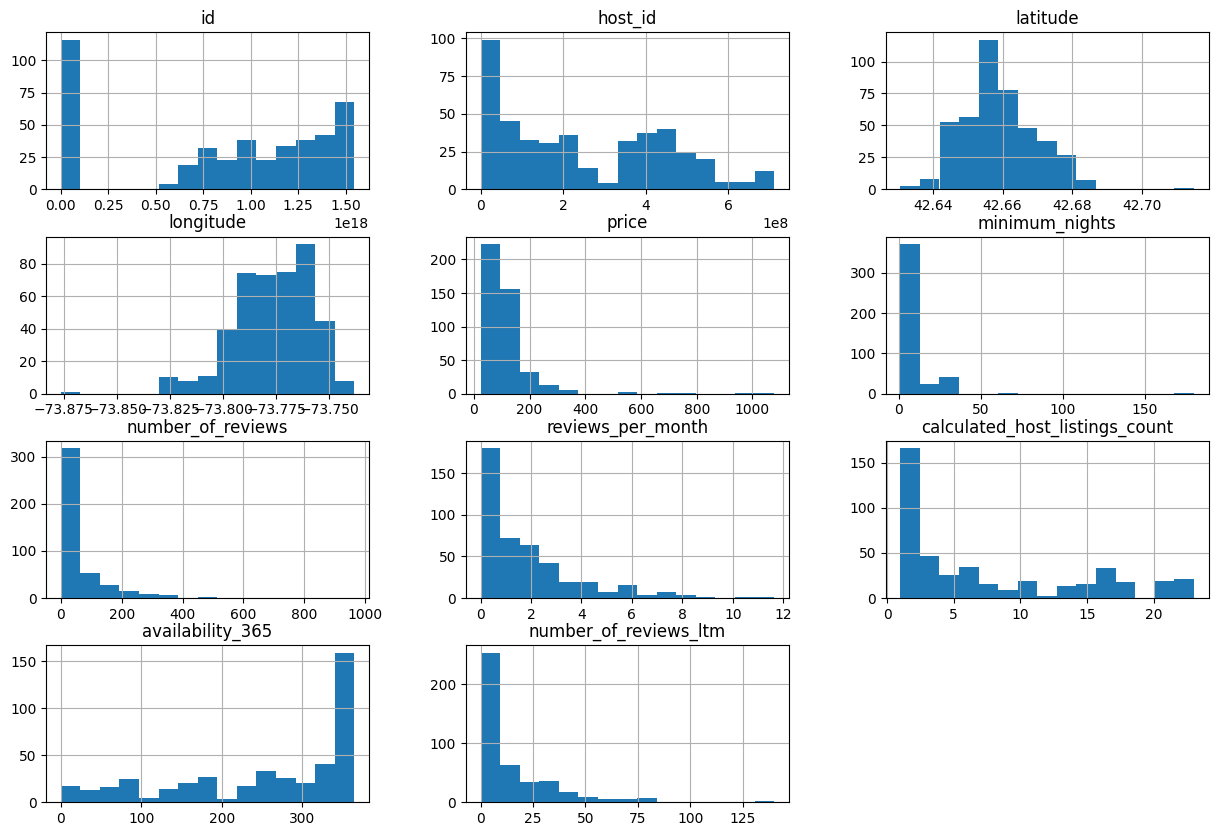

In [ ]:
df_airbnb.hist(bins=15, figsize=(15,10));


##**Q4. Are there outliers present?**
---
From the histogram distribution, it is possible to observe indications of the presence of *outliers*. For example, take a look at the variables `price`, `minimum_nights`, and `calculated_host_listings_count`.

* `minimum_nights` = **180:** “Does the guest have to stay for 6 MONTHS?”
* `calculated_host_listings_count` = **23:** “One person with 23 properties? A real superhost or duplicated listings?”
* `price` = **$1078:** “A mansion? It could be real, but it skews the average!”

The values do not follow a distribution and distort the entire graphical representation. To confirm this, there are two quick methods that help detect outliers. They are:


* Statistical summary using the `describe()` method
* Plot `boxplots` for the variable


In [ ]:
df_airbnb[['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month',
    'calculated_host_listings_count', 'availability_365']].describe()

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,437.000000,437.000000,437.000000,437.000000,437.000000,437.000000
mean,113.693364,5.640732,63.336384,1.791533,7.514874,254.148741
std,98.820114,12.216941,115.043167,1.975050,7.179091,113.076488
min,24.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,68.000000,1.000000,3.000000,0.310000,2.000000,170.000000
50%,94.000000,2.000000,20.000000,1.160000,4.000000,296.000000
75%,122.000000,3.000000,73.000000,2.650000,13.000000,355.000000
max,1078.000000,180.000000,964.000000,11.640000,23.000000,365.000000


##Looking at the statistical summary above, we can confirm some hypotheses such as:
----
* The `price` variable has **75%** of its values below **122**, however, its maximum value is **1078**.
*  The minimum number of nights (`minimum_nights`) exceeds **180** days in a year.



# Boxplot to Price

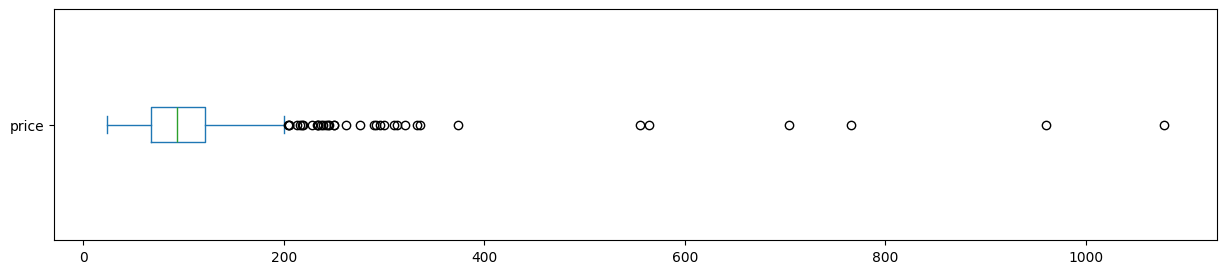

In [ ]:
# price
df_airbnb.price.plot(kind='box', vert=False, figsize=(15, 3),)
plt.show()



### Boxplot to minimum_nights

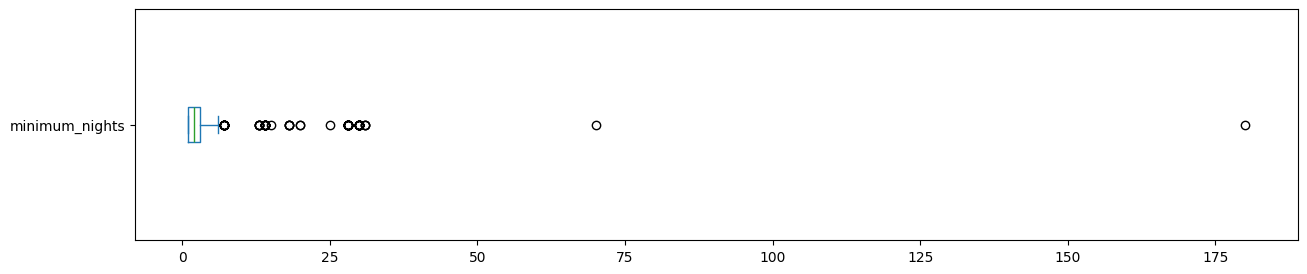

In [ ]:
# minimum_nights
df_airbnb.minimum_nights.plot(kind='box', vert=False, figsize=(15, 3))
plt.show()


#### Histograms without *outliers*

Since we identified *outliers* in the `price` and `minimum_nights` variables, we will now clean the *DataFrame* by removing them and plot the histogram again.


In [ ]:
# remove outliers in a new DataFrame

df_clean = df_airbnb.copy()
df_clean.drop(df_clean[df_clean.price > 400].index, axis = 0 , inplace = True)
df_clean.drop(df_clean[df_clean.minimum_nights > 30].index, axis = 0 , inplace = True)

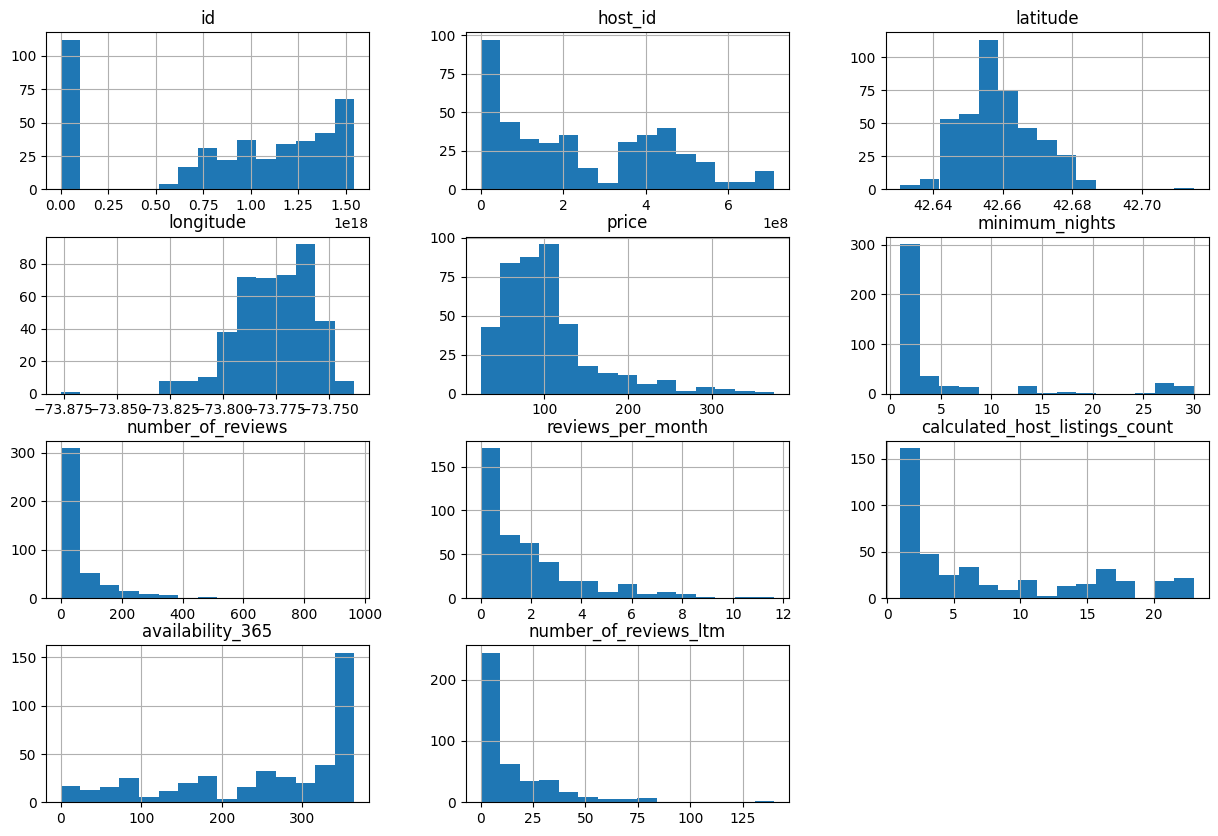

In [ ]:
df_clean.hist(bins=15, figsize=(15,10));

### **Q4. What is the correlation between the variables?**

Correlation means that there is a relationship between two things. In our context, we are looking for relationships or similarities between two variables.

This relationship can be measured, and the correlation coefficient is responsible for determining its strength. To identify the correlations between the variables of interest, I will:

* Create a correlation matrix
* Generate a *heatmap* from this matrix using the `seaborn` library


In [ ]:
# create a correlation matrix

corr = df_clean[['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month',
    'calculated_host_listings_count', 'availability_365']].corr()

display(corr)

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
price,1.000000,-0.133608,-0.008638,0.046513,-0.128092,-0.073996
minimum_nights,-0.133608,1.000000,-0.218959,-0.363511,0.028707,0.014716
number_of_reviews,-0.008638,-0.218959,1.000000,0.672012,-0.067197,-0.046617
reviews_per_month,0.046513,-0.363511,0.672012,1.000000,-0.046239,0.020463
calculated_host_listings_count,-0.128092,0.028707,-0.067197,-0.046239,1.000000,-0.093908
availability_365,-0.073996,0.014716,-0.046617,0.020463,-0.093908,1.000000


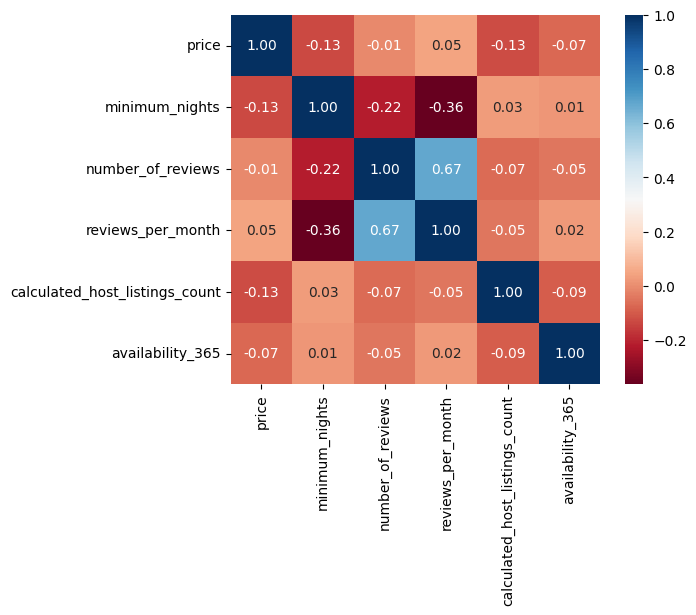

In [ ]:
sns.heatmap(corr, cmap='RdBu', fmt='.2f', square=True, linecolor='white', annot=True);

### **Q5. What type of property is most rented on Airbnb?**

The `room_type` variable indicates the type of listing available on Airbnb. If you have ever used the platform, you know that there are options such as entire homes/apartments, private rooms, or even shared rooms.

Let’s count the number of occurrences of each type of rental using the `value_counts()` method.


In [ ]:
# show the number of each type of available property

df_clean.room_type.value_counts()

,count
room_type,
Entire home/apt,315
Private room,111


In [ ]:
# show the percentage of each type of available property
df_clean.room_type.value_counts()/ len(df_clean) * 100

,count
room_type,
Entire home/apt,73.943662
Private room,26.056338


### **Q6. What is the most expensive location in Albany?(NY)**
---
* To investigate the relationship between geographic location and accommodation cost, we applied the groupby() function. This technique allows us to aggregate the data by district and compare average prices. The dictionary then provides the necessary context to interpret the dataset's 'Wards', mapping them to the modern neighborhood names of Albany and explaining the observed price variations.

In [ ]:
df_clean.groupby(['neighbourhood']).price.mean().sort_values(ascending=False)[:10]

,price
neighbourhood,
FIFTEENTH WARD,156.615385
EIGHTH WARD,155.400000
FIRST WARD,146.000000
TWELFTH WARD,137.000000
SEVENTH WARD,127.466667
SECOND WARD,122.826087
FOURTEENTH WARD,107.200000
TENTH WARD,107.187500
FOURTH WARD,103.733333


###Neighborhood Analysis: Albany, NY Wards
---
* **Data Note**: The listings.csv dataset represents Albany (New York's State Capital). The "Wards" listed below are the official administrative divisions of the city.



###District (Ward) and Modern Neighborhood      
---

`FIFTEENTH WARD` -  Buckingham Lake:
*  **Upscale Residential:** The highest price point in the analysis. Known for luxury homes and scenic parks.  

`EIGHTH WARD`  - West Hill:

* **Residential Growth:** Offers larger properties with competitive pricing; currently seeing urban renewal.   

`FIRST WARD`      - South End:  
*  **Historic/Industrial:** Located near the Hudson River; attracts guests looking for loft-style accommodations.  

`TWELFTH WARD `  - Washington Park:  
* **Premium Location:** Surrounds the city's main park. High demand due to events and proximity to University at Albany.      

`SEVENTH WARD`   - Park South:
*  **Institutional:** Strategically located near major medical centers and hospitals (Albany Med).

`SECOND WARD`    - The Pastures:
*  **Heritage District:** Features restored 19th-century architecture. Attracts guests seeking a historic experience.  

`FOURTEENTH WARD `- New Scotland:
* **Safe & Quiet:** A stable residential zone with local shops and a high "walkability" score.    

`TENTH WARD `  -  Pine Hills:
*  **Student Heart:** Very diverse area with a mix of Victorian homes and student housing.    

`FOURTH WARD `  - Downtown:
*  **Business District:** Near the MVP Arena and government offices. High activity during the work week.

`SIXTH WARD `  - Center Square:
*  **Cultural Hub:** The most vibrant area. Historic brownstones, nightlife, and walking distance to the State Capitol.   
-----

**Since latitude and longitude are provided for the properties, it is possible to plot each point. For this, we consider `x = longitude` and `y = latitude`.**


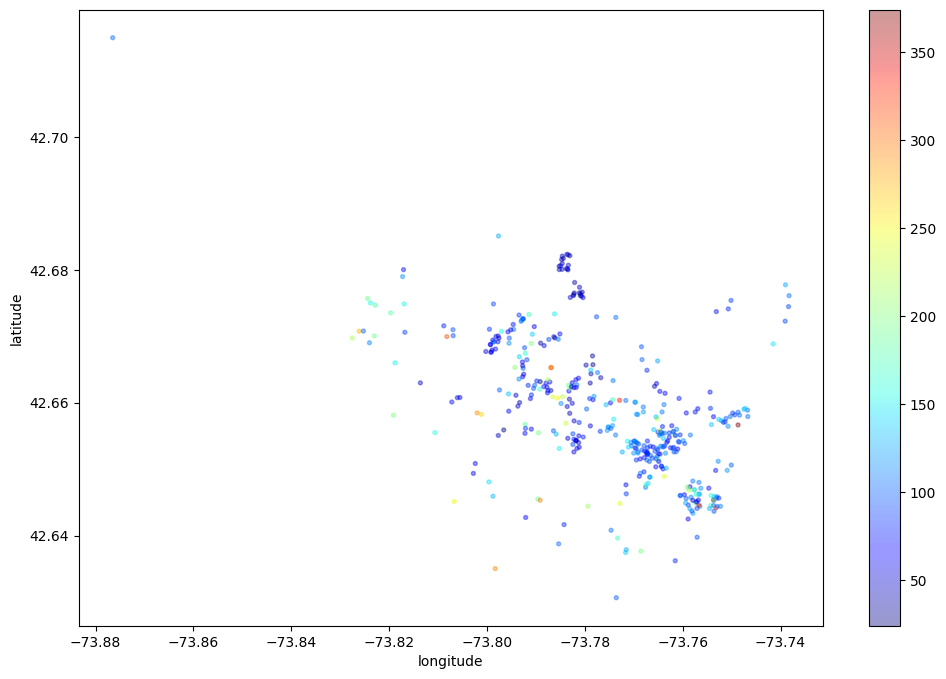

In [ ]:
df_clean.plot(kind="scatter", x='longitude', y='latitude', alpha=0.4, c=df_clean['price'], s=8,
              cmap=plt.get_cmap('jet'), figsize=(12,8));

###Conclusion
----
* The analysis of the Airbnb dataset for the city of Albany (New York) proved to be quite insightful, even though it was conducted in a simplified manner. The diversity of available variables allowed us to explore different aspects of the dataset and better understand price behavior and the distribution of accommodations in the region.
Initially, a data preprocessing step was carried out, focusing on identifying and handling missing values. Although the missing data did not represent a significant issue for the analysis, we chose to remove or properly treat them, ensuring greater consistency and reliability in the results.
Next, we used histogram plots to obtain an overall view of the distribution of variables, especially prices. This initial step was essential to raise important questions, such as the presence of extreme values (outliers) and the overall shape of the data distribution. For instance, a wide variation in prices was observed, ranging from very low to extremely high values.
However, since histograms do not always clearly reveal the presence of outliers, we conducted a complementary analysis using descriptive statistics (mean, median, and percentiles) along with boxplots. These tools confirmed the existence of outliers that could potentially distort the analysis.
As a result, outlier treatment was performed, always preserving a copy of the original dataset to maintain data integrity. After this step, we repeated the initial exploratory analysis, which provided a more accurate view of the data behavior without the influence of extreme or inconsistent values.
With the cleaned data, we were able to move forward with more focused analyses, such as identifying the most expensive neighborhoods and investigating the factors influencing these prices. Additionally, the use of heatmaps based on latitude and longitude helped visualize the geographical distribution of accommodations, revealing relevant spatial patterns.
Finally, this analysis demonstrated how essential preprocessing steps—such as handling missing values and removing outliers—are to ensure more accurate and reliable results, as well as to generate more consistent insights from the dataset. As a complement, the study also provided a better understanding of the city of Albany, the capital of New York State, which was previously unfamiliar to me.

*** I appreciate the opportunity to develop this work and, lastly, I express my gratitude to God for everything.***